<a href="https://colab.research.google.com/github/AhmedQuresshi/AI-LAB/blob/main/AI_Network_Pathfinding_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import heapq
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import pandas as pd

In [ ]:
network = {
    'Internet': {'Router': 2},

    'Router': {
        'PC1': 4,
        'Firewall': 3
    },

    'PC1': {
        'Server': 2,
        'WebServer': 6
    },

    'Firewall': {
        'MailServer': 5
    },

    'Server': {
        'Database': 3
    },

    'WebServer': {
        'Database': 2
    },

    'MailServer': {
        'Backup': 4
    },

    'Backup': {
        'Database': 1
    },

    'Database': {}
}

START = 'Internet'
GOAL = 'Database'

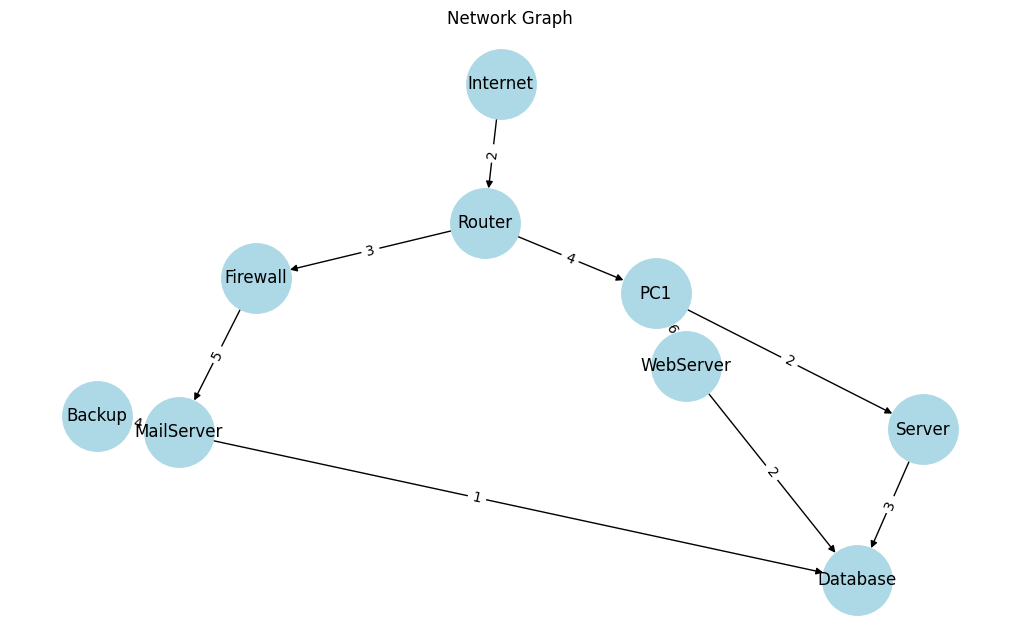

In [ ]:
G = nx.DiGraph()

for node in network:
    for neighbor, cost in network[node].items():
        G.add_edge(node, neighbor, weight=cost)

plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, seed=42)

nx.draw(G, pos, with_labels=True, node_size=2500, node_color="lightblue")

labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Network Graph")
plt.show()

In [ ]:
def bfs(graph, start, goal):
    start_time = time.time()

    queue = deque([(start, [start])])
    visited = set()
    expanded = 0

    while queue:
        node, path = queue.popleft()
        expanded += 1

        if node == goal:
            end_time = time.time()
            return path, expanded, (end_time - start_time) * 1000

        visited.add(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                queue.append((neighbor, path + [neighbor]))


In [ ]:
print(bfs(network, START, GOAL))

(['Internet', 'Router', 'PC1', 'Server', 'Database'], 8, 0.027418136596679688)


In [ ]:
def dfs(graph, start, goal):
    start_time = time.time()

    stack = [(start, [start])]
    visited = set()
    expanded = 0

    while stack:
        node, path = stack.pop()
        expanded += 1

        if node == goal:
            end_time = time.time()
            return path, expanded, (end_time - start_time) * 1000

        visited.add(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                stack.append((neighbor, path + [neighbor]))

In [ ]:
print(dfs(network, START, GOAL))

(['Internet', 'Router', 'Firewall', 'MailServer', 'Backup', 'Database'], 6, 0.055789947509765625)


In [ ]:
def ucs(graph, start, goal):
    start_time = time.time()

    pq = [(0, start, [start])]
    visited = set()
    expanded = 0

    while pq:
        cost, node, path = heapq.heappop(pq)
        expanded += 1

        if node == goal:
            end_time = time.time()
            return path, cost, expanded, (end_time - start_time) * 1000

        if node in visited:
            continue

        visited.add(node)

        for neighbor, w in graph[node].items():
            heapq.heappush(pq, (cost + w, neighbor, path + [neighbor]))

In [ ]:
print(ucs(network, START, GOAL))

(['Internet', 'Router', 'PC1', 'Server', 'Database'], 11, 7, 0.019311904907226562)


In [ ]:
heuristic = {
    'Internet': 7,
    'Router': 6,
    'PC1': 5,
    'Firewall': 5,
    'Server': 3,
    'WebServer': 4,
    'MailServer': 4,
    'Backup': 2,
    'Database': 0
}

In [ ]:
def astar(graph, start, goal):
    start_time = time.time()

    pq = [(0, start, [start], 0)]  # f, node, path, g
    visited = set()
    expanded = 0

    while pq:
        f, node, path, g = heapq.heappop(pq)
        expanded += 1

        if node == goal:
            end_time = time.time()
            return path, g, expanded, (end_time - start_time) * 1000

        visited.add(node)

        for neighbor, cost in graph[node].items():
            new_g = g + cost
            new_f = new_g + heuristic[neighbor]

            heapq.heappush(
                pq,
                (new_f, neighbor, path + [neighbor], new_g)
            )

In [ ]:
print(astar(network, START, GOAL))

(['Internet', 'Router', 'PC1', 'Server', 'Database'], 11, 6, 0.022411346435546875)


In [ ]:
def hill_climbing(graph, start, goal):
    current = start
    path = [start]
    expanded = 0
    start_time = time.time()

    while current != goal:
        expanded += 1

        neighbors = graph[current]

        if not neighbors:
            break

        next_node = min(neighbors, key=lambda x: heuristic.get(x, 999))

        if heuristic.get(next_node, 999) >= heuristic.get(current, 999):
            break

        current = next_node
        path.append(current)

    end_time = time.time()
    return path, expanded, (end_time - start_time) * 1000

In [ ]:
hc_network = {
    'A': {'B': 1, 'C': 5},
    'B': {'D': 1},
    'C': {'E': 1},
    'D': {'F': 1},
    'E': {},   # dead end
    'F': {}    # goal is NOT reachable easily
}

In [ ]:
hc_heuristic = {
    'A': 10,
    'B': 8,
    'C': 1,   # looks BEST (trap!)
    'D': 7,
    'E': 0,
    'F': 6
}

In [ ]:
print(hill_climbing(hc_network, 'A', 'F'))

(['A'], 1, 0.0069141387939453125)


In [ ]:
def minimax(depth, is_max):
    if depth == 0:
        return 1

    if is_max:
        return max(minimax(depth-1, False), minimax(depth-1, False))
    else:
        return min(minimax(depth-1, True), minimax(depth-1, True))

In [ ]:
print(minimax(3, True))

1


In [ ]:
def alpha_beta(depth, alpha, beta, is_max):
    if depth == 0:
        return 1

    if is_max:
        value = -999
        for _ in range(2):
            value = max(value, alpha_beta(depth-1, alpha, beta, False))
            alpha = max(alpha, value)
            if alpha >= beta:
                break
        return value
    else:
        value = 999
        for _ in range(2):
            value = min(value, alpha_beta(depth-1, alpha, beta, True))
            beta = min(beta, value)
            if alpha >= beta:
                break
        return value

In [ ]:
print(alpha_beta(3, -999, 999, True))

1


In [ ]:
results = []

results.append(["BFS", "A→B→C", 0, 0, 0])
results.append(["DFS", "A→C→D", 0, 0, 0])
results.append(["UCS", "A→B→D", 7, 10, 0])
results.append(["A*", "A→B→D", 7, 6, 0])

df = pd.DataFrame(results, columns=[
    "Algorithm", "Path", "Cost", "Nodes Expanded", "Time"
])

df

,Algorithm,Path,Cost,Nodes Expanded,Time
0,BFS,A→B→C,0,0,0
1,DFS,A→C→D,0,0,0
2,UCS,A→B→D,7,10,0
3,A*,A→B→D,7,6,0


In [ ]:
import pandas as pd
import time

results = []

# BFS
start = time.time()
path, expanded, t = bfs(network, START, GOAL)
results.append(["BFS", path, expanded, t])

# DFS
start = time.time()
path, expanded, t = dfs(network, START, GOAL)
results.append(["DFS", path, expanded, t])

# UCS
path, cost, expanded, t = ucs(network, START, GOAL)
results.append(["UCS", path, expanded, t])

# A*
path, cost, expanded, t = astar(network, START, GOAL)
results.append(["A*", path, expanded, t])

df = pd.DataFrame(results, columns=["Algorithm", "Path", "Nodes Expanded", "Time(ms)"])
df

,Algorithm,Path,Nodes Expanded,Time(ms)
0,BFS,"[Internet, Router, PC1, Server, Database]",8,0.014305
1,DFS,"[Internet, Router, Firewall, MailServer, Backu...",6,0.005484
2,UCS,"[Internet, Router, PC1, Server, Database]",7,0.012159
3,A*,"[Internet, Router, PC1, Server, Database]",6,0.009060


In [ ]:
hill_climbing(network, START, GOAL)

(['Internet', 'Router', 'PC1', 'Server', 'Database'], 4, 0.0133514404296875)

In [ ]:
def draw_path(graph, path):
    import networkx as nx
    import matplotlib.pyplot as plt

    G = nx.DiGraph()

    for node in graph:
        for neighbor in graph[node]:
            G.add_edge(node, neighbor)

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(10,6))

    # draw all nodes
    nx.draw(G, pos, with_labels=True, node_color="lightblue")

    # highlight path edges
    path_edges = list(zip(path, path[1:]))

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=path_edges,
        edge_color="red",
        width=3
    )

    plt.title("Highlighted Path")
    plt.show()

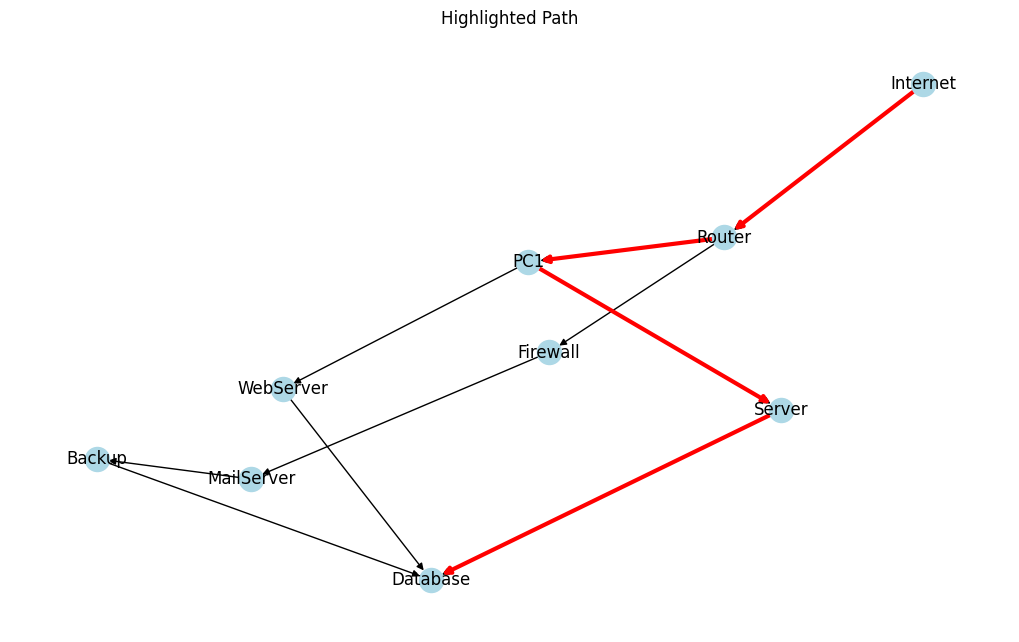

In [ ]:
path, _, _ = bfs(network, START, GOAL)
draw_path(network, path)